## Sampling and reconstruction

In [5]:
from numpy import *
from numpy.fft import ifft, fftfreq, fftshift
from matplotlib.pyplot import *

### Create the 'continuous' signal starting from a finite support Fourier transform

$$
\text{triangle spectrum}\qquad X(f) = 
\begin{cases}
1 - \frac{|f|}{f_\text{max}}\ ,& |f| \leq f_\text{max} \\
0 & |f| > f_\text{max}
\end{cases}
$$

$$
x(t) = \mathcal{F}^{-1}[X(f)](t)
$$

In [16]:
# We shall create a 'continuous' signal with a triangle shaped Fourier transform
dt = 0.001 
fs = 1/dt # resolution of the 'continuous' signal

fmax = 4.0 # maximum frequency (half width of the triangle)
N = 4096 # the size of our 'continuous' signal: N points, i.e. N*T long
f = fftfreq(N, dt) # the 'continous' Fourier transform will have the same number of points at the same number of frequencies
X = zeros(N)
X[abs(f) <= fmax] = (1 - abs(f)/fmax)[abs(f) <= fmax] # triangle shape
X  # the peak is at index 0. Good!

array([1.        , 0.93896484, 0.87792969, ..., 0.81689453, 0.87792969,
       0.93896484])

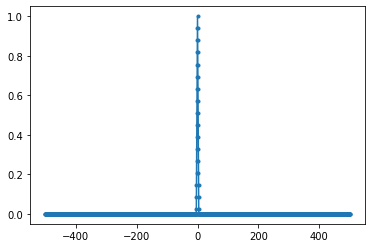

In [17]:
plot(fftshift(f), fftshift(X), '.-')

(-10.0, 10.0)

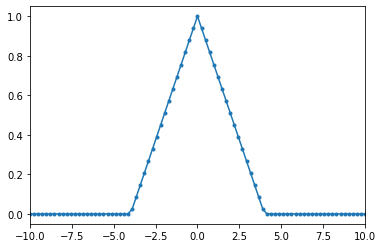

In [8]:
plot(fftshift(f), fftshift(X), '.-')
xlim([-10,10]) # zoom in to see better (non-interactive)

In [9]:
# get the signal as inverse Fourier transform
x = fs*real(ifft(X)) # N*(fs/N)*ifft(X)
x

array([4.00352478, 4.00331389, 4.00268129, ..., 4.00162713, 4.00268129,
       4.00331389])

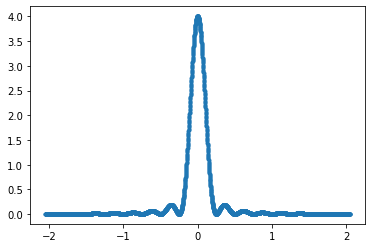

In [10]:
t = fftfreq(N, fs/N)
plot(fftshift(t), fftshift(x), '.-')
# Now we have our 'continuous' signal in x.

### Sampling

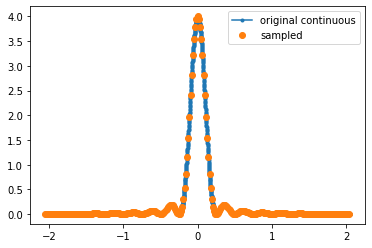

In [21]:
# Let's sample it by keeping only every 16th points
m = 16
T = dt*m # this is the sampling period
xhat  = x[::m] # sampled (discrete time) signal
tsamp = t[::m] # sampled time
plot(fftshift(t), fftshift(x), '.-', label='original continuous')
plot(fftshift(tsamp), fftshift(xhat), 'o', label='sampled')
legend()

### Reconstruction

$$
			\!\!\begin{aligned}
					{x}(t) &= 	\mathcal{F}^{-1}[{X}](t)=
					\hat{x}\ast \frac{1}{T}\operatorname{sinc}_\pi(t/T)=\\
					&=\sum_{n=-\infty}^\infty\!\!\!\! x[n]\dfrac{\sin\pi(t-nT)/T}{\pi(t-nT)/T}\ .
			\end{aligned}
$$

(-0.2, 0.2)

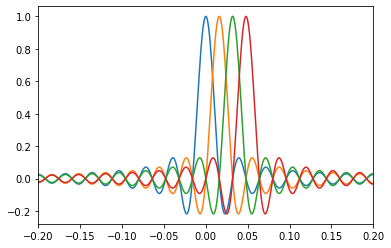

In [19]:
def sincpi(x):
    x[x == 0] = 1e-13 # to avoid problems when dividint with it
    return sin(pi*x)/(pi*x)
# these are the different shifted 'sinc' functions the linear combination of which reconstructs the original 'continuous' signal
plot(fftshift(t), fftshift(sincpi(t/T)))
plot(fftshift(t), fftshift(sincpi(t/T - 1)))
plot(fftshift(t), fftshift(sincpi(t/T - 2)))
plot(fftshift(t), fftshift(sincpi(t/T - 3)))
xlim([-0.2, 0.2])

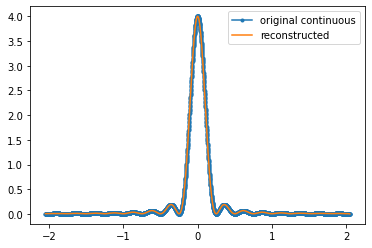

In [24]:
Nsamp = N//m # size of the sampled signal (the same as len(xhat))
xrec = zeros(len(t)) # the reconstructed signal ('continuous')
for n in arange(-Nsamp//2, Nsamp//2):
    xrec += xhat[n]*sincpi(t/T - n)
plot(fftshift(t), fftshift(x), '.-', label='original continuous')
plot(fftshift(t), fftshift(xrec), '-', label='reconstructed')
legend()